# Investimento Público em Educação e Taxa de Desemprego na América Latina
## Uma Análise Descritiva da Última Década
**Disciplina:** EAE1106 – Métodos Computacionais para Economia  
**Prof.:** Arthur Viaro — 1º Semestre de 2026  
**Autor:** Messias Victor Assunção Ribeiro do Nascimento  
**Fonte dos dados:** World Bank Open Data (snapshot versionado em CSV; coleta via `wbgapi` documentada em `coletar_dados_api.py`)  
**Indicadores:** SE.XPD.TOTL.GD.ZS e SL.UEM.TOTL.ZS

---
## 1. Instalação e Importação de Bibliotecas

In [1]:
# Instalação das dependências (executar apenas uma vez)
# !pip install -r requirements.txt
# (ou)  !pip install pandas matplotlib seaborn scipy numpy

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import mannwhitneyu

plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid', palette='muted')

print('Bibliotecas importadas com sucesso!')
print(f'pandas v{pd.__version__} | numpy v{np.__version__}')

Bibliotecas importadas com sucesso!
pandas v3.0.3 | numpy v2.4.6


---
## 2. Coleta de Dados

Os dados brutos provêm da **API pública do Banco Mundial** (World Bank Open Data,
indicadores abaixo). Para garantir reprodutibilidade exata, eles estão versionados
como um *snapshot* em CSV no repositório do grupo:

- `dados_brutos_paises.csv` — séries por país (formato longo)
- `dados_brutos_regional_LCN.csv` — agregado regional (América Latina e Caribe)

O notebook **reconstrói toda a análise a partir desses arquivos brutos**. O script
`coletar_dados_api.py` documenta como o snapshot foi obtido da API (reexecutável
para atualizar os dados).

| Código | Descrição |
|--------|----------|
| `SE.XPD.TOTL.GD.ZS` | Gasto público em educação (% do PIB) |
| `SL.UEM.TOTL.ZS` | Taxa de desemprego total (% da força de trabalho) |

In [2]:
# ==============================================================================
# ETAPA 1: PARÂMETROS DO ESTUDO
# ==============================================================================
# Indicadores do Banco Mundial usados na coleta (ver coletar_dados_api.py).
indicadores = {
    'SE.XPD.TOTL.GD.ZS': 'Gasto_Educacao_pct_PIB',
    'SL.UEM.TOTL.ZS': 'Taxa_Desemprego'
}

# Conjunto de 18 países da América Latina e Caribe inicialmente considerados.
# Após o critério de cobertura (>= 70% em ambos os indicadores, ver Etapa 4),
# permanecem os 10 países presentes no snapshot de dados brutos.
paises_candidatos = [
    'Brasil', 'México', 'Argentina', 'Colômbia', 'Chile', 'Peru', 'Equador',
    'Bolívia', 'Paraguai', 'Uruguai', 'Venezuela', 'Costa Rica', 'Panamá',
    'Guatemala', 'Honduras', 'El Salvador', 'Nicarágua', 'Rep. Dominicana'
]

anos = range(2010, 2023)

print(f'Período de análise: {min(anos)}-{max(anos)}')
print(f'Países candidatos considerados: {len(paises_candidatos)}')
print(f'Indicadores: {list(indicadores.values())}')

Período de análise: 2010-2022
Países candidatos considerados: 18
Indicadores: ['Gasto_Educacao_pct_PIB', 'Taxa_Desemprego']


In [3]:
# ==============================================================================
# ETAPA 2: CARGA DO AGREGADO REGIONAL (América Latina e Caribe — LCN)
# ==============================================================================
# Lê o snapshot de dados brutos versionado no repositório.

df_regional = pd.read_csv('dados_brutos_regional_LCN.csv')

print(f'Agregado regional carregado: {df_regional.shape[0]} anos x {df_regional.shape[1]} colunas')
df_regional

Agregado regional carregado: 13 anos x 3 colunas


,Ano,Gasto_Educacao_pct_PIB,Taxa_Desemprego
0,2010,4.58,6.74
1,2011,4.62,6.67
2,2012,4.70,6.42
3,2013,4.73,6.18
4,2014,4.84,6.04
5,2015,4.87,6.25
6,2016,4.95,7.83
7,2017,4.91,8.43
8,2018,4.88,7.87
9,2019,4.82,8.10


In [4]:
# ==============================================================================
# ETAPA 3: CARGA DOS DADOS POR PAÍS
# ==============================================================================
# Lê o snapshot de dados brutos versionado no repositório (formato longo).
# A coluna 'Pais' é renomeada para 'economy' (usada no restante da análise).

df_paises = pd.read_csv('dados_brutos_paises.csv').rename(columns={'Pais': 'economy'})

print(f'Base por países: {df_paises.shape[0]} obs x {df_paises.shape[1]} colunas')
print(f'Países no snapshot: {df_paises["economy"].nunique()}')
print(f'\nValores ausentes:\n{df_paises.isnull().sum()}')
df_paises.head(10)

Base por países: 130 obs x 4 colunas
Países no snapshot: 10

Valores ausentes:
economy                   0
Ano                       0
Gasto_Educacao_pct_PIB    0
Taxa_Desemprego           0
dtype: int64


,economy,Ano,Gasto_Educacao_pct_PIB,Taxa_Desemprego
0,Argentina,2010,5.11,7.71
1,Argentina,2011,5.17,7.17
2,Argentina,2012,5.52,7.16
3,Argentina,2013,5.31,7.07
4,Argentina,2014,5.42,7.27
5,Argentina,2015,5.51,6.54
6,Argentina,2016,5.54,8.46
7,Argentina,2017,5.49,8.35
8,Argentina,2018,5.40,9.16
9,Argentina,2019,5.61,10.56


---
## 3. Limpeza e Construção da Base de Dados

In [5]:
# ==============================================================================
# ETAPA 4: TRATAMENTO DE VALORES AUSENTES E FILTRAGEM DA AMOSTRA
# ==============================================================================

completude = (
    df_paises.groupby('economy')[['Gasto_Educacao_pct_PIB', 'Taxa_Desemprego']]
    .apply(lambda x: x.notna().mean() * 100)
    .round(1)
)
completude.columns = ['% completo - Educação', '% completo - Desemprego']
print('Completude dos dados por país (%):')
print(completude.to_string())

# Manter apenas países com >= 70% de completude em ambas as variáveis
paises_validos = completude[
    (completude['% completo - Educação'] >= 70) &
    (completude['% completo - Desemprego'] >= 70)
].index.tolist()

df_analise = df_paises[df_paises['economy'].isin(paises_validos)].copy()
print(f'\nPaíses na amostra final: {len(paises_validos)}')
print(f'Observações: {len(df_analise)}')

Completude dos dados por país (%):
            % completo - Educação  % completo - Desemprego
economy                                                   
Argentina                   100.0                    100.0
Bolívia                     100.0                    100.0
Brasil                      100.0                    100.0
Chile                       100.0                    100.0
Colômbia                    100.0                    100.0
Costa Rica                  100.0                    100.0
Equador                     100.0                    100.0
México                      100.0                    100.0
Peru                        100.0                    100.0
Uruguai                     100.0                    100.0

Países na amostra final: 10
Observações: 130


In [6]:
# ==============================================================================
# ETAPA 5: CLASSIFICAÇÃO POR NÍVEL DE INVESTIMENTO
# ==============================================================================

media_gasto = (
    df_analise.groupby('economy')['Gasto_Educacao_pct_PIB']
    .mean().reset_index()
    .rename(columns={'Gasto_Educacao_pct_PIB': 'Gasto_Medio'})
)

mediana_global = media_gasto['Gasto_Medio'].median()
media_gasto['Grupo_Investimento'] = media_gasto['Gasto_Medio'].apply(
    lambda x: 'Alto Investimento' if x >= mediana_global else 'Baixo Investimento'
)

df_analise = df_analise.merge(
    media_gasto[['economy', 'Grupo_Investimento']], on='economy', how='left'
)

print('Classificação dos países por nível de investimento:')
print(media_gasto.sort_values('Gasto_Medio', ascending=False).to_string(index=False))
print(f'\nMediana global de gasto: {mediana_global:.2f}% do PIB')

Classificação dos países por nível de investimento:
   economy  Gasto_Medio Grupo_Investimento
Costa Rica     7.153846  Alto Investimento
   Bolívia     6.820769  Alto Investimento
    Brasil     5.896154  Alto Investimento
 Argentina     5.312308  Alto Investimento
    México     5.080769  Alto Investimento
  Colômbia     4.770000 Baixo Investimento
     Chile     4.750000 Baixo Investimento
   Uruguai     4.689231 Baixo Investimento
   Equador     4.675385 Baixo Investimento
      Peru     3.644615 Baixo Investimento

Mediana global de gasto: 4.93% do PIB


---
## 4. Análise Descritiva

In [7]:
# ==============================================================================
# ESTATÍSTICAS DESCRITIVAS GERAIS
# ==============================================================================

variaveis = ['Gasto_Educacao_pct_PIB', 'Taxa_Desemprego']
desc = df_analise[variaveis].describe().round(2)
desc.index = ['N', 'Média', 'Desvio-padrão', 'Mínimo',
              '1º Quartil', 'Mediana', '3º Quartil', 'Máximo']
print('ESTATÍSTICAS DESCRITIVAS - BASE CONSOLIDADA')
print(desc.to_string())

print('\nESTATÍSTICAS POR GRUPO DE INVESTIMENTO')
grupo_stats = df_analise.groupby('Grupo_Investimento')[variaveis].agg(
    ['mean', 'median', 'std']
).round(2)
print(grupo_stats.to_string())

ESTATÍSTICAS DESCRITIVAS - BASE CONSOLIDADA
               Gasto_Educacao_pct_PIB  Taxa_Desemprego
N                              130.00           130.00
Média                            5.28             7.38
Desvio-padrão                    1.06             3.00
Mínimo                           2.77             3.24
1º Quartil                       4.60             4.96
Mediana                          5.06             6.86
3º Quartil                       5.92             9.27
Máximo                           7.67            20.02

ESTATÍSTICAS POR GRUPO DE INVESTIMENTO
                   Gasto_Educacao_pct_PIB              Taxa_Desemprego             
                                     mean median   std            mean median   std
Grupo_Investimento                                                                 
Alto Investimento                    6.05   5.93  0.88            7.36   6.92  3.51
Baixo Investimento                   4.51   4.67  0.54            7.39   6.83  2.41


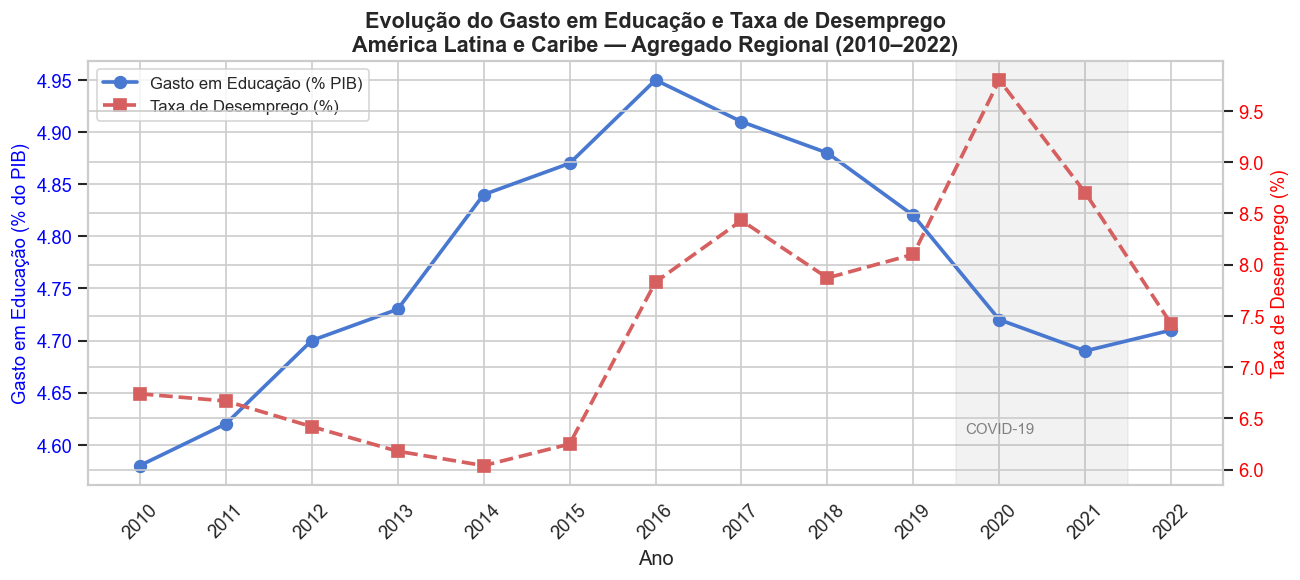

In [8]:
# ==============================================================================
# FIGURA 1: EVOLUÇÃO TEMPORAL DO AGREGADO REGIONAL
# ==============================================================================

fig, ax1 = plt.subplots(figsize=(11, 5))
ax2 = ax1.twinx()

ax1.plot(df_regional['Ano'], df_regional['Gasto_Educacao_pct_PIB'],
         'b-o', linewidth=2.2, markersize=7, label='Gasto em Educação (% PIB)')
ax2.plot(df_regional['Ano'], df_regional['Taxa_Desemprego'],
         'r--s', linewidth=2.2, markersize=7, label='Taxa de Desemprego (%)')

ax1.set_xlabel('Ano', fontsize=12)
ax1.set_ylabel('Gasto em Educação (% do PIB)', color='blue', fontsize=11)
ax2.set_ylabel('Taxa de Desemprego (%)', color='red', fontsize=11)
ax1.tick_params(axis='y', labelcolor='blue')
ax2.tick_params(axis='y', labelcolor='red')
ax1.set_xticks(df_regional['Ano'])
ax1.set_xticklabels(df_regional['Ano'], rotation=45)
ax1.axvspan(2019.5, 2021.5, alpha=0.10, color='gray')
ax1.text(2020, ax1.get_ylim()[0]+0.05, 'COVID-19', fontsize=9, color='gray', ha='center')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, loc='upper left', fontsize=10)
plt.title('Evolução do Gasto em Educação e Taxa de Desemprego\n'
          'América Latina e Caribe — Agregado Regional (2010–2022)',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig1_evolucao_regional.png', dpi=150, bbox_inches='tight')
plt.show()

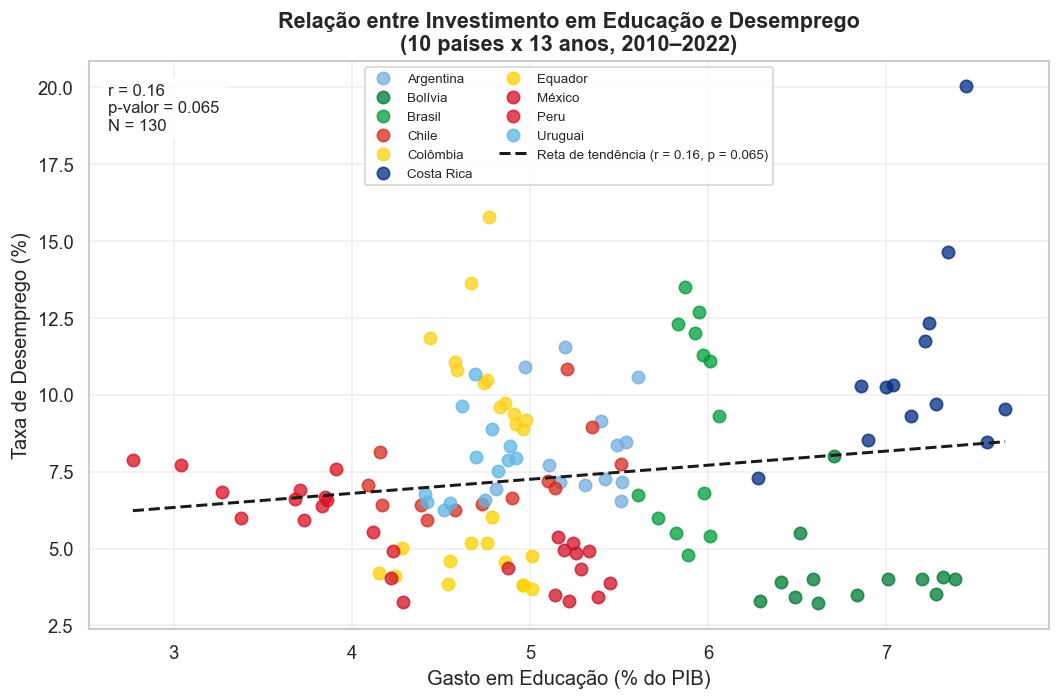

Correlação de Pearson: r = 0.162, p = 0.0654


In [9]:
# ==============================================================================
# FIGURA 2: SCATTER PLOT — CORRELAÇÃO AGREGADA
# ==============================================================================

df_clean = df_analise.dropna(subset=['Gasto_Educacao_pct_PIB', 'Taxa_Desemprego'])
slope, intercept, r, p, se = stats.linregress(
    df_clean['Gasto_Educacao_pct_PIB'], df_clean['Taxa_Desemprego']
)

cores_paises = {
    'Brasil': '#009C3B', 'México': '#CE1126', 'Argentina': '#74ACDF',
    'Colômbia': '#FCD116', 'Chile': '#D52B1E', 'Peru': '#D91023',
    'Equador': '#FFD100', 'Bolívia': '#007A33', 'Uruguai': '#5EB6E4',
    'Costa Rica': '#002B7F'
}

fig, ax = plt.subplots(figsize=(9, 6))
for pais in df_clean['economy'].unique():
    d = df_clean[df_clean['economy'] == pais]
    ax.scatter(d['Gasto_Educacao_pct_PIB'], d['Taxa_Desemprego'],
               label=pais, alpha=0.75, s=55, color=cores_paises.get(pais, 'gray'))

x_line = np.linspace(df_clean['Gasto_Educacao_pct_PIB'].min(),
                     df_clean['Gasto_Educacao_pct_PIB'].max(), 100)
ax.plot(x_line, slope*x_line+intercept, 'k--', linewidth=1.8,
        label=f'Reta de tendência (r = {r:.2f}, p = {p:.3f})')

ax.set_xlabel('Gasto em Educação (% do PIB)', fontsize=12)
ax.set_ylabel('Taxa de Desemprego (%)', fontsize=12)
ax.set_title('Relação entre Investimento em Educação e Desemprego\n'
             '(10 países x 13 anos, 2010–2022)', fontsize=13, fontweight='bold')
ax.legend(fontsize=8, ncol=2)
ax.grid(alpha=0.3)
ax.text(0.02, 0.96, f'r = {r:.2f}\np-valor = {p:.3f}\nN = {len(df_clean)}',
        transform=ax.transAxes, fontsize=10, va='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
plt.tight_layout()
plt.savefig('fig2_scatter_correlacao.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Correlação de Pearson: r = {r:.3f}, p = {p:.4f}')

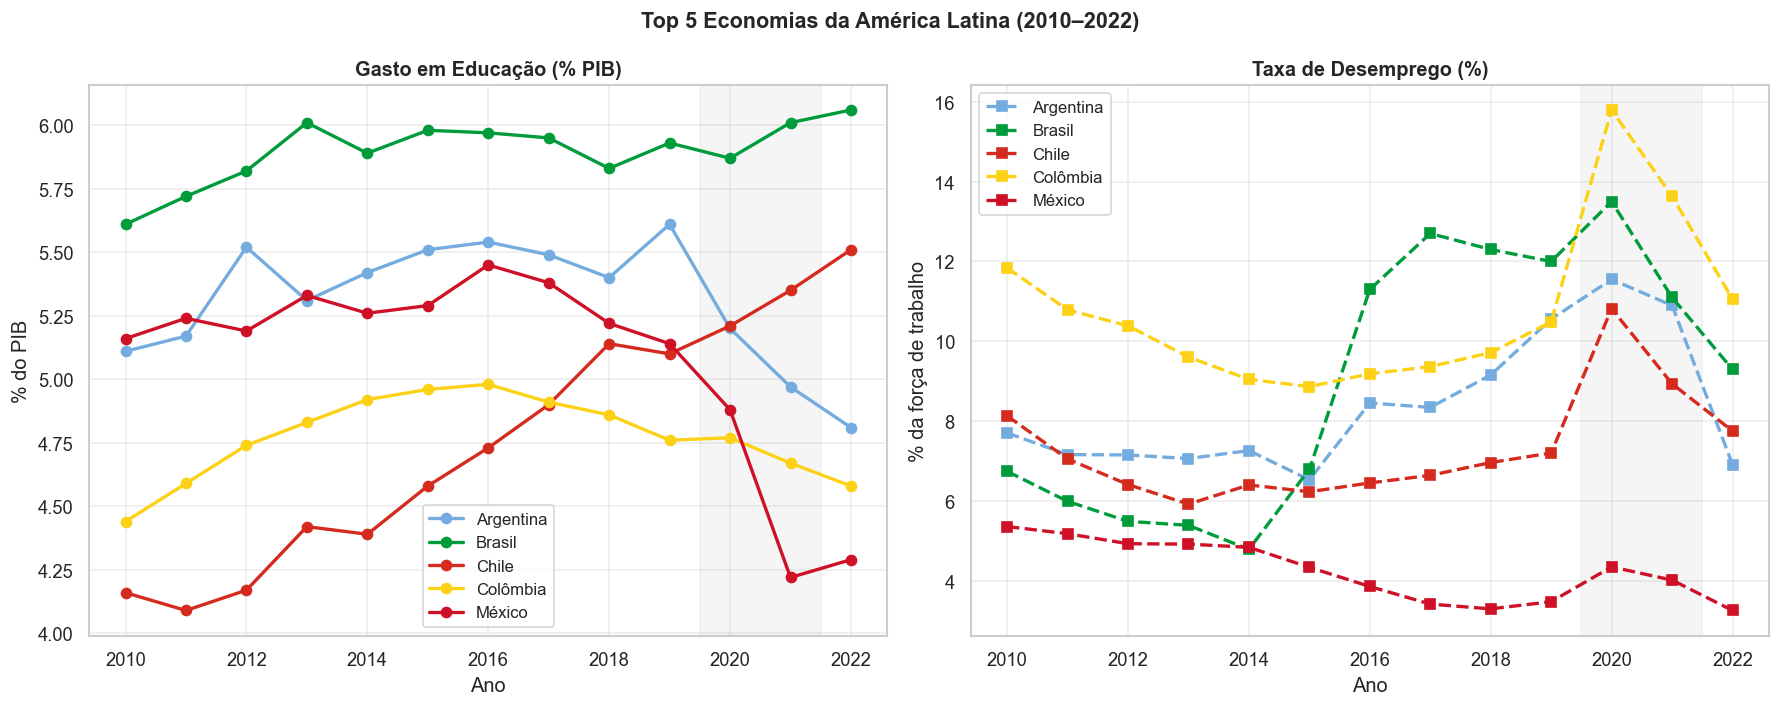

In [10]:
# ==============================================================================
# FIGURA 3: COMPARATIVO TOP 5 ECONOMIAS
# ==============================================================================

top5 = ['Brasil', 'México', 'Argentina', 'Colômbia', 'Chile']
df5 = df_analise[df_analise['economy'].isin(top5)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
cores5 = {'Brasil': '#009C3B', 'México': '#CE1126', 'Argentina': '#74ACDF',
          'Colômbia': '#FCD116', 'Chile': '#D52B1E'}

for pais, dados_pais in df5.groupby('economy'):
    d = dados_pais.sort_values('Ano')
    ax1.plot(d['Ano'], d['Gasto_Educacao_pct_PIB'],
             marker='o', label=pais, linewidth=2, color=cores5[pais])
    ax2.plot(d['Ano'], d['Taxa_Desemprego'],
             marker='s', label=pais, linewidth=2, linestyle='--', color=cores5[pais])

for ax in [ax1, ax2]:
    ax.set_xticks(range(2010, 2023, 2))
    ax.grid(True, alpha=0.35)
    ax.legend(fontsize=10)
    ax.set_xlabel('Ano')
    ax.axvspan(2019.5, 2021.5, alpha=0.08, color='gray')

ax1.set_title('Gasto em Educação (% PIB)', fontsize=12, fontweight='bold')
ax1.set_ylabel('% do PIB')
ax2.set_title('Taxa de Desemprego (%)', fontsize=12, fontweight='bold')
ax2.set_ylabel('% da força de trabalho')
plt.suptitle('Top 5 Economias da América Latina (2010–2022)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig3_top5_comparativo.png', dpi=150, bbox_inches='tight')
plt.show()

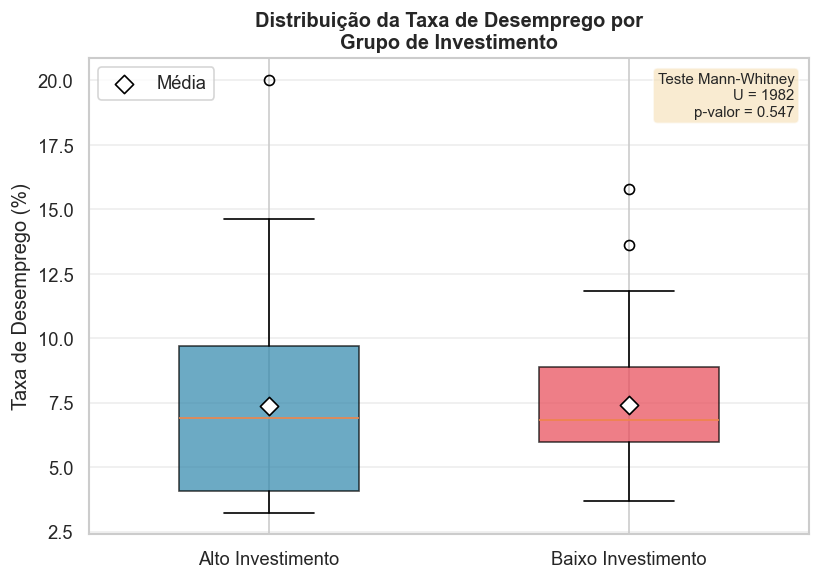

Mann-Whitney: U = 1982, p = 0.5465
Alto Investimento: média = 7.36%, mediana = 6.92%
Baixo Investimento: média = 7.39%, mediana = 6.83%


In [11]:
# ==============================================================================
# FIGURA 4: BOXPLOT POR GRUPO + TESTE DE MANN-WHITNEY
# ==============================================================================

grupos_lista = ['Alto Investimento', 'Baixo Investimento']
data_grupos = [
    df_analise[df_analise['Grupo_Investimento'] == g]['Taxa_Desemprego'].dropna().values
    for g in grupos_lista
]

stat_mw, p_mw = mannwhitneyu(data_grupos[0], data_grupos[1], alternative='two-sided')

fig, ax = plt.subplots(figsize=(7, 5))
cores_box = {'Alto Investimento': '#2E86AB', 'Baixo Investimento': '#E84855'}
bp = ax.boxplot(data_grupos, tick_labels=grupos_lista, patch_artist=True, widths=0.5)
for patch, g in zip(bp['boxes'], grupos_lista):
    patch.set_facecolor(cores_box[g])
    patch.set_alpha(0.7)

for i, dados in enumerate(data_grupos, 1):
    ax.scatter(i, np.mean(dados), color='white', edgecolors='black',
               zorder=5, s=60, marker='D', label='Média' if i == 1 else '')

ax.set_ylabel('Taxa de Desemprego (%)', fontsize=12)
ax.set_title('Distribuição da Taxa de Desemprego por\nGrupo de Investimento',
             fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.35)
ax.legend()
ax.text(0.98, 0.97, f'Teste Mann-Whitney\nU = {stat_mw:.0f}\np-valor = {p_mw:.3f}',
        transform=ax.transAxes, ha='right', va='top', fontsize=9,
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.6))
plt.tight_layout()
plt.savefig('fig4_boxplot_grupos.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Mann-Whitney: U = {stat_mw:.0f}, p = {p_mw:.4f}')
for i, g in enumerate(grupos_lista):
    print(f'{g}: média = {np.mean(data_grupos[i]):.2f}%, mediana = {np.median(data_grupos[i]):.2f}%')

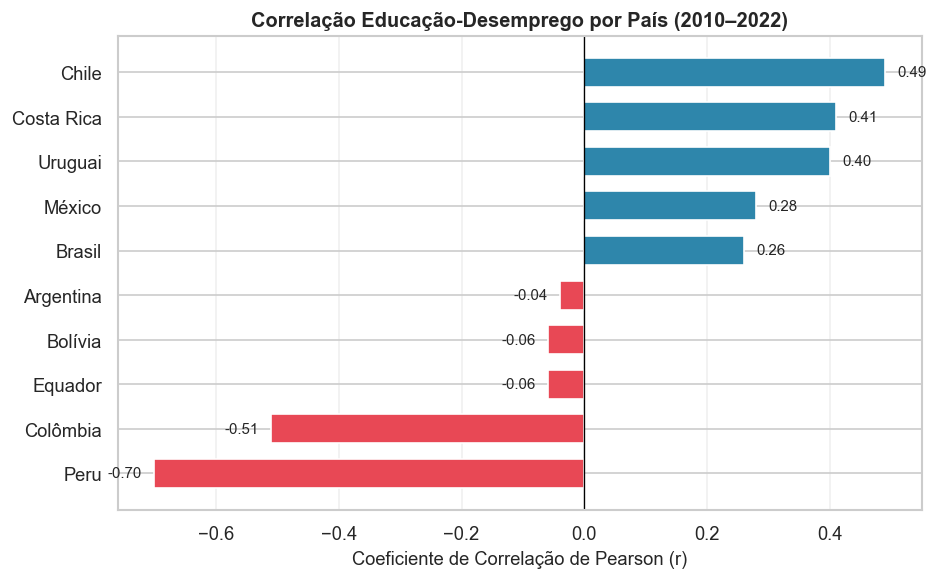

      País     r     p    n
      Peru -0.70 0.007 13.0
  Colômbia -0.51 0.078 13.0
   Equador -0.06 0.853 13.0
   Bolívia -0.06 0.852 13.0
 Argentina -0.04 0.905 13.0
    Brasil  0.26 0.386 13.0
    México  0.28 0.351 13.0
   Uruguai  0.40 0.181 13.0
Costa Rica  0.41 0.162 13.0
     Chile  0.49 0.091 13.0


In [12]:
# ==============================================================================
# FIGURA 5: CORRELAÇÃO POR PAÍS (BARRAS HORIZONTAIS)
# ==============================================================================

correlacoes = {}
for pais in df_analise['economy'].unique():
    d = df_analise[df_analise['economy'] == pais].dropna(
        subset=['Gasto_Educacao_pct_PIB', 'Taxa_Desemprego']
    )
    if len(d) >= 5:
        r_c, p_c = stats.pearsonr(d['Gasto_Educacao_pct_PIB'], d['Taxa_Desemprego'])
        correlacoes[pais] = {'r': round(r_c, 2), 'p': round(p_c, 3), 'n': len(d)}

corr_df = (
    pd.DataFrame(correlacoes).T.reset_index()
    .rename(columns={'index': 'País'})
    .sort_values('r')
)

fig, ax = plt.subplots(figsize=(8, 5))
colors_bar = ['#E84855' if v < 0 else '#2E86AB' for v in corr_df['r']]
bars = ax.barh(corr_df['País'], corr_df['r'], color=colors_bar,
               edgecolor='white', height=0.65)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coeficiente de Correlação de Pearson (r)', fontsize=11)
ax.set_title('Correlação Educação-Desemprego por País (2010–2022)',
             fontsize=12, fontweight='bold')
for bar, val in zip(bars, corr_df['r']):
    ax.text(val + (0.02 if val >= 0 else -0.02),
            bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center',
            ha='left' if val >= 0 else 'right', fontsize=9)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('fig5_correlacao_paises.png', dpi=150, bbox_inches='tight')
plt.show()
print(corr_df[['País', 'r', 'p', 'n']].to_string(index=False))

In [13]:
# ==============================================================================
# ANÁLISE DE DEFASAGEM TEMPORAL (LAG)
# ==============================================================================

def correlacao_com_lag(df, pais, lag=2):
    '''Correlação entre Gasto em Educação (t-lag) e Desemprego (t).'''
    d = df[df['economy'] == pais].sort_values('Ano').dropna(
        subset=['Gasto_Educacao_pct_PIB', 'Taxa_Desemprego']
    )
    if len(d) <= lag + 2:
        return None, None
    edu_lag = d['Gasto_Educacao_pct_PIB'].shift(lag)
    des = d['Taxa_Desemprego']
    mask = edu_lag.notna() & des.notna()
    if mask.sum() < 4:
        return None, None
    r, p = stats.pearsonr(edu_lag[mask], des[mask])
    return round(r, 2), round(p, 3)

print(f"{'País':<20} {'r (sem lag)':>12} {'r (lag=2)':>10} {'p (lag=2)':>10}")
print('-' * 60)
for pais in sorted(df_analise['economy'].unique()):
    r_s = correlacoes.get(pais, {}).get('r', 'N/A')
    r_l, p_l = correlacao_com_lag(df_analise, pais, lag=2)
    if r_l is not None:
        print(f'{pais:<20} {str(r_s):>12} {r_l:>10} {p_l:>10}')

País                  r (sem lag)  r (lag=2)  p (lag=2)
------------------------------------------------------------
Argentina                   -0.04       0.61      0.044
Bolívia                     -0.06       0.17      0.622
Brasil                       0.26       0.58      0.061
Chile                        0.49       0.79      0.004
Colômbia                    -0.51      -0.01      0.978
Costa Rica                   0.41       0.05      0.879
Equador                     -0.06       0.41      0.208
México                       0.28      -0.08      0.826
Peru                         -0.7      -0.13      0.695
Uruguai                       0.4       0.83      0.002


---
## 5. Interpretação dos Resultados

### 5.1 Tendência Regional
A análise do agregado regional (LCN) revela crescimento gradual no gasto público em educação (~4,6% a ~4,7% do PIB entre 2010 e 2022). O desemprego exibiu comportamento mais volátil, influenciado por crises econômicas internas e pela pandemia de COVID-19 em 2020.

### 5.2 Correlação Geral
O coeficiente de Pearson (r ≈ 0,16, p ≈ 0,065) é fraco e não significativo ao nível de 5%, refletindo as múltiplas forças simultâneas que afetam o desemprego.

### 5.3 Heterogeneidade entre Países
A análise por país revela heterogeneidade expressiva. Peru (r = -0,70) e Colômbia (r = -0,51) apresentam correlação negativa, consistente com a hipótese. Brasil e Chile exibem correlação positiva, provavelmente dominada por choques macroeconômicos contemporâneos.

### 5.4 Defasagem Temporal
A análise com lag de 2 anos não produz padrão uniforme entre países, resultado esperado dado o horizonte temporal limitado e a heterogeneidade estrutural da região.

### 5.5 Grupos de Investimento
A comparação entre grupos (teste Mann-Whitney, p ≈ 0,55) não apresenta diferença estatisticamente significativa, o que é esperado dada a amostra limitada e a ausência de controles para variáveis de confusão.

---
## 6. Limitações e Próximos Passos

### Limitações
1. **Causalidade:** análise puramente descritiva, sem inferência causal.
2. **Omissão de variáveis:** crescimento do PIB, estrutura produtiva e qualidade do gasto não são controlados.
3. **Dados ausentes:** exclusão de países com baixa cobertura pode introduzir viés de seleção.
4. **Heterogeneidade:** América Latina é muito diversa para ser tratada como bloco homogêneo.

### Próximos Passos
1. **Dados em painel com efeitos fixos** para controlar heterogeneidade não observada.
2. **Variáveis de controle:** PIB per capita, taxa de investimento, qualidade educacional.
3. **Análise de cointegração** para relações de longo prazo.
4. **Desagregação por nível educacional** (fundamental, médio, superior).
5. **Desemprego formal vs. informal** para capturar nuances do mercado latino-americano.